# 📧 Email Spam Detection using Machine Learning

This project uses machine learning to classify emails as Spam or Not Spam.

## Objective
To build a machine learning classification model that can automatically detect spam emails based on word-frequency features.

## Model Used
- Random Forest Classifier
- SMOTE for handling class imbalance

## Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Precision-Recall Curve
- Confusion Matrix

## Dataset

- Total emails: 5,172
- Total columns: 3,002
- Target variable: `Prediction`
- `0` = Not Spam
- `1` = Spam
- `Email No.` is an identifier and is excluded from model training.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import(
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    auc,
    roc_curve,
    roc_auc_score,
    precision_recall_curve
)
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

# Load Dataset
df = pd.read_csv("dataset/emails.csv")

In [3]:
df.shape

(5172, 3002)

In [4]:
df.columns

Index(['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou',
       ...
       'connevey', 'jay', 'valued', 'lay', 'infrastructure', 'military',
       'allowing', 'ff', 'dry', 'Prediction'],
      dtype='object', length=3002)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5172 entries, 0 to 5171
Columns: 3002 entries, Email No. to Prediction
dtypes: int64(3001), object(1)
memory usage: 118.5+ MB


In [6]:
df.head(5)

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [7]:
df.isnull().sum()

Email No.     0
the           0
to            0
ect           0
and           0
             ..
military      0
allowing      0
ff            0
dry           0
Prediction    0
Length: 3002, dtype: int64

In [8]:
# Feature and Target
X = df.drop(columns=["Email No.","Prediction"])
y = df['Prediction']

In [9]:
df['Prediction'].value_counts()

Prediction
0    3672
1    1500
Name: count, dtype: int64

In [10]:
# Train-Test-Split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Apply SMOTE ONLY on training data

smote = SMOTE(random_state=42)
X_train_smote,y_train_smote = smote.fit_resample(
    X_train,
    y_train,
)

print('Before SMOTE: ')
print(y_train.value_counts())

print('\nAfter SMOTE: ')
print(y_train_smote.value_counts())


Before SMOTE: 
Prediction
0    2937
1    1200
Name: count, dtype: int64

After SMOTE: 
Prediction
0    2937
1    2937
Name: count, dtype: int64


In [11]:
# Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Training
model.fit(X_train_smote,y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
# Accuracy
y_pred = model.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test,y_pred):.4f}')

Accuracy: 0.9739


<Figure size 600x500 with 0 Axes>

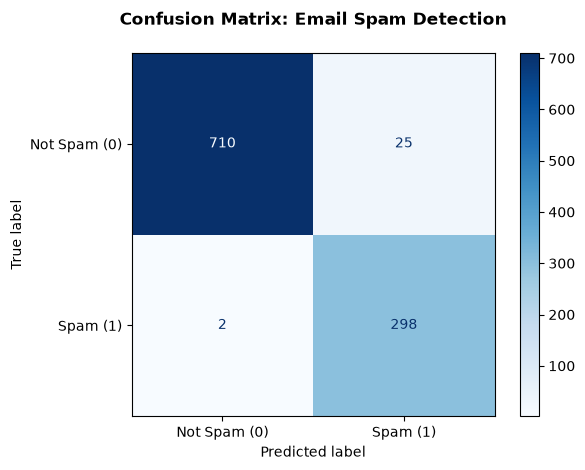

In [13]:
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Not Spam (0)','Spam (1)'])

# Using 'Reds' or 'Blues' to emphasize the contrast
disp.plot(cmap='Blues',values_format='d')
plt.title('Confusion Matrix: Email Spam Detection\n',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
print(f'Precision: {precision_score(y_test,y_pred):.4f}')

Precision: 0.9226


In [15]:
print(f'Recall: {recall_score(y_test,y_pred):.4f}')

Recall: 0.9933


In [16]:
print(f'F1 Score: {f1_score(y_test,y_pred):.4f}')

F1 Score: 0.9567


In [17]:
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:,1]
y_probs

array([0.12, 0.25, 0.27, ..., 1.  , 0.  , 0.76], shape=(1035,))

In [23]:
print(f'ROC-AUC Score: {roc_auc_score(y_test,y_probs):.4f}')

ROC-AUC Score: 0.9960


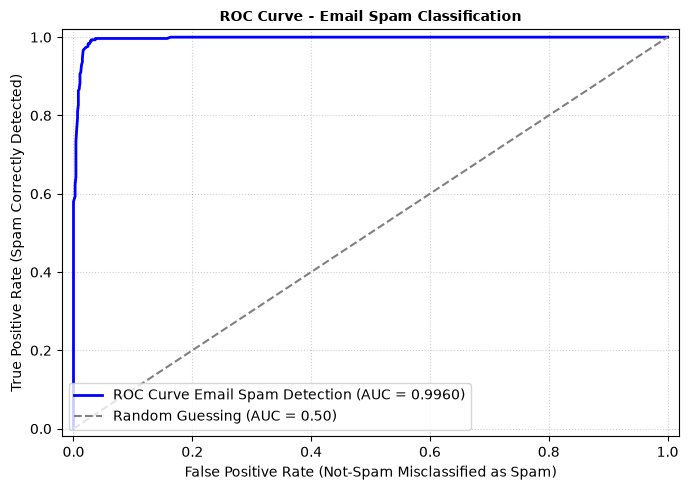

In [22]:
plt.figure(figsize=(7,5))
fpr,tpr,_ = roc_curve(y_test,y_probs)
roc_auc = roc_auc_score(y_test,y_probs)

plt.plot(fpr,
         tpr,
         color='blue',
         lw=2,
         label=f'ROC Curve Email Spam Detection (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1],color='grey',lw=1.5,linestyle="--",label='Random Guessing (AUC = 0.50)')

plt.xlim([-0.02,1.02])
plt.ylim([-0.02,1.02])
plt.xlabel('False Positive Rate (Not-Spam Misclassified as Spam)',fontsize=10)
plt.ylabel('True Positive Rate (Spam Correctly Detected)',fontsize=10)
plt.title('ROC Curve - Email Spam Classification',fontsize=10,fontweight='bold')
plt.legend(loc='lower left',frameon=True)
plt.grid(True,linestyle=":",alpha=0.6)
plt.tight_layout()
plt.show()

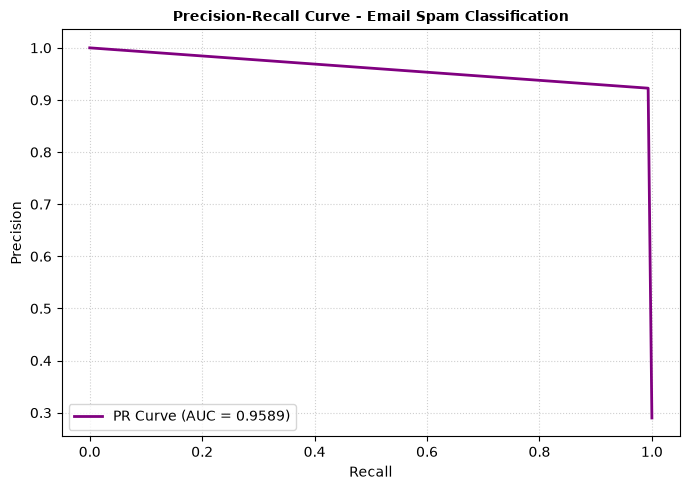

In [ ]:
plt.figure(figsize=(7,5))
precision_vals,recall_vals,_ = precision_recall_curve(y_test,y_probs)
pr_auc = auc(recall_vals,precision_vals)

plt.plot(recall_vals,
         precision_vals,
         color='purple',
         lw=2,
         label=f'PR Curve (AUC = {pr_auc:.4f})')

plt.xlabel('Recall',fontsize=10)
plt.ylabel('Precision',fontsize=10)
plt.title('Precision-Recall Curve - Email Spam Classification',fontsize=10,fontweight='bold')
plt.legend(loc='lower left')
plt.grid(True,linestyle=':',alpha=0.6)
plt.tight_layout()
plt.show()

In [24]:
# Final Email Classification

precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
roc_auc = roc_auc_score(y_test,y_probs)
pr_auc = auc(recall_vals,precision_vals)

print('Final Email Classification')
print('-'*30)
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1 Score  : {f1:.4f}')
print(f'ROC-AUC   : {roc_auc:.4f}')
print(f'PR-AUC    : {pr_auc:.4f}')

Final Email Classification
------------------------------
Precision : 0.9226
Recall    : 0.9933
F1 Score  : 0.9567
ROC-AUC   : 0.9960
PR-AUC    : 0.9589
